# Create Matched Test Images

This notebook creates 10 test images from both synthetic and original datasets with identical:
- Dimensions (512x512)
- Proper windowing (using metadata for originals)
- No artifacts/annotations

**Output folders:**
- `/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/test_synthetic_resized/`
- `/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/test_original_matched/`


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
import glob
from tqdm import tqdm
import random

print("Libraries imported successfully!")


Libraries imported successfully!


## Step 1: Setup Paths and Create Output Folders


In [2]:
# Input paths (READ ONLY)
SYNTHETIC_PATH = '/raid/mpsych/OMAMA/DATA/data/train/'
NPZ_PATH = '/hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/2d_resized_512/images/'
METADATA_PATH = '/hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/2d_resized_512/metadata/'

# Output paths (NEW - we'll create these)
OUTPUT_BASE = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/'
SYNTHETIC_OUTPUT = os.path.join(OUTPUT_BASE, 'test_synthetic_resized')
ORIGINAL_OUTPUT = os.path.join(OUTPUT_BASE, 'test_original_matched')

# Create output directories
os.makedirs(SYNTHETIC_OUTPUT, exist_ok=True)
os.makedirs(ORIGINAL_OUTPUT, exist_ok=True)

print(f"✓ Created output folder: {SYNTHETIC_OUTPUT}")
print(f"✓ Created output folder: {ORIGINAL_OUTPUT}")


✓ Created output folder: /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/test_synthetic_resized
✓ Created output folder: /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/test_original_matched


## Step 2: Select 10 Test Images


In [3]:
# Get synthetic images (first 10)
synthetic_files = sorted(glob.glob(os.path.join(SYNTHETIC_PATH, '*.png')))[:10]

# Get random 10 NPZ files
npz_files = sorted(glob.glob(os.path.join(NPZ_PATH, '*.npz')))
random.seed(42)  # For reproducibility
selected_npz = random.sample(npz_files, 10)

print(f"Selected {len(synthetic_files)} synthetic images")
print(f"Selected {len(selected_npz)} original NPZ files")
print("\nSynthetic samples:")
for f in synthetic_files:
    print(f"  {os.path.basename(f)}")
print("\nOriginal NPZ samples:")
for f in selected_npz:
    print(f"  {os.path.basename(f)}")


Selected 10 synthetic images
Selected 10 original NPZ files

Synthetic samples:
  sample_0.png
  sample_1.png
  sample_10.png
  sample_100.png
  sample_1000.png
  sample_10000.png
  sample_10001.png
  sample_10002.png
  sample_10003.png
  sample_10004.png

Original NPZ samples:
  114623062851627323745523138777782264053.npz
  10313488422822981314752731593021630171.npz
  141773236724015206122534435075171225192.npz
  136064393820710012176183595248777360960.npz
  132231550101355084432166268976796846338.npz
  118729579140397605947822934288967989110.npz
  113324582846621011084116026367947065521.npz
  232336598205570228354356158639557397136.npz
  111181835140697996379202911706536969324.npz
  276800006434526083548281996325769971337.npz


## Step 3: Process Synthetic Images (640x512 → 512x512)


In [4]:
def center_crop_640_to_512(img):
    """
    Center crop from (640, 512) to (512, 512)
    Removes 64 pixels from top and 64 pixels from bottom
    """
    if img.shape[0] == 640:
        return img[64:576, :]
    return img

print("Processing synthetic images...\n")
for syn_file in tqdm(synthetic_files, desc="Cropping synthetic images"):
    # Load image
    img = cv2.imread(syn_file, cv2.IMREAD_GRAYSCALE)
    
    # Center crop
    cropped = center_crop_640_to_512(img)
    
    # Save with same filename
    output_path = os.path.join(SYNTHETIC_OUTPUT, os.path.basename(syn_file))
    cv2.imwrite(output_path, cropped)

print(f"\n✓ Processed {len(synthetic_files)} synthetic images")
print(f"✓ Saved to: {SYNTHETIC_OUTPUT}")


Processing synthetic images...



Cropping synthetic images: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 141.83it/s]


✓ Processed 10 synthetic images
✓ Saved to: /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/test_synthetic_resized


## Step 4: Process Original NPZ Images (Apply Metadata Windowing)


In [5]:
def apply_dicom_windowing(pixel_array, window_center, window_width, 
                          rescale_intercept=0, rescale_slope=1):
    """
    Apply DICOM windowing to convert raw pixel values to display range [0, 255]
    
    Parameters:
    - pixel_array: Raw pixel data from NPZ
    - window_center: From metadata JSON
    - window_width: From metadata JSON
    - rescale_intercept: From metadata JSON (default 0)
    - rescale_slope: From metadata JSON (default 1)
    """
    # Convert to float for calculations
    pixel_array = pixel_array.astype(np.float32)
    
    # Apply rescale slope and intercept
    pixel_array = pixel_array * rescale_slope + rescale_intercept
    
    # Calculate window min and max
    img_min = window_center - window_width / 2
    img_max = window_center + window_width / 2
    
    # Apply windowing
    windowed = np.clip(pixel_array, img_min, img_max)
    
    # Normalize to [0, 255]
    windowed = ((windowed - img_min) / (img_max - img_min) * 255).astype(np.uint8)
    
    return windowed

print("Testing windowing function...")
print("✓ Function defined successfully")


Testing windowing function...
✓ Function defined successfully


In [6]:
# Debug: Check one metadata file to see the structure
debug_json = os.path.join(METADATA_PATH, os.path.basename(selected_npz[0]).replace('.npz', '.json'))
with open(debug_json, 'r') as f:
    sample_metadata = json.load(f)

print("Sample metadata structure:")
print(json.dumps(sample_metadata, indent=2))
print(f"\nWindowCenter type: {type(sample_metadata.get('WindowCenter'))}")
print(f"WindowWidth type: {type(sample_metadata.get('WindowWidth'))}")


Sample metadata structure:
{
  "PatientID": "DHO029OCUFOE",
  "View": "cranio-caudal",
  "WindowCenter": [
    2689.0,
    2725.0,
    2623.0
  ],
  "WindowWidth": [
    900.0,
    750.0,
    1050.0
  ],
  "WindowCenterWidthExplanation": [
    "NORMAL",
    "HARDER",
    "SOFTER"
  ],
  "ImagerPixelSpacing": [
    0.09409090909091,
    0.09409090909091
  ],
  "ImageLaterality": "L",
  "coords": [
    6,
    167,
    63,
    218
  ],
  "score": 0.03350649029016495,
  "label": "NonCancer"
}

WindowCenter type: <class 'list'>
WindowWidth type: <class 'list'>


## 🔍 DEBUG: Test Different Preprocessing Methods

The DICOM windowing is creating clinical views (dark background). Let's test what preprocessing the GAN actually used.


NPZ file keys: ['data']

Raw NPZ data:
  Key used: 'data'
  Shape: (512, 512)
  Dtype: uint16
  Min: 994, Max: 3196
  Mean: 1241.5


/tmp/ipykernel_3057341/2410995059.py:82: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/a.kanamarlapudi001/miniconda3/envs/tf_gpu_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


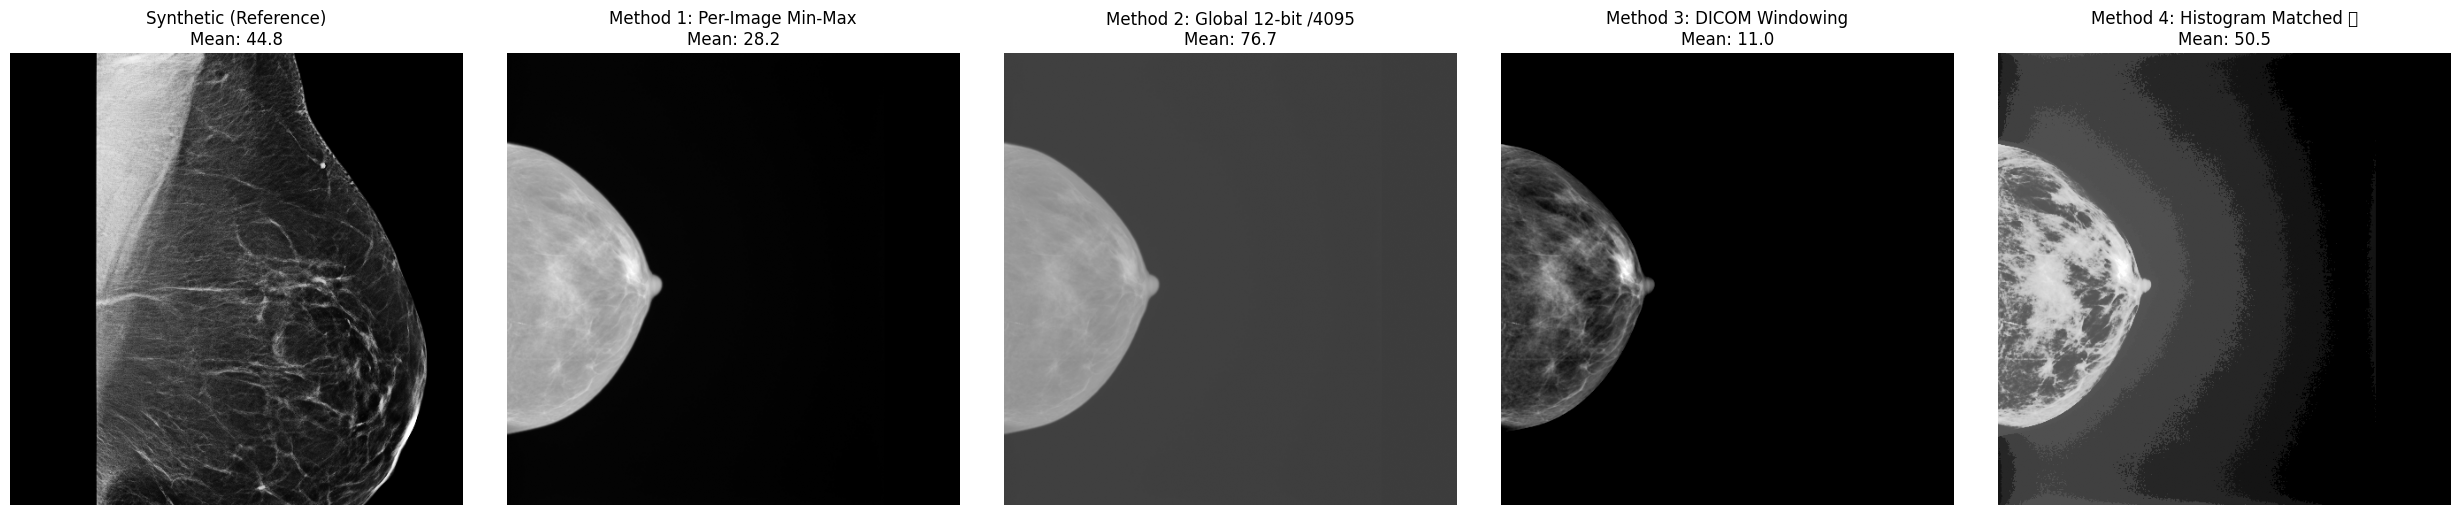


📊 Method 4 (Histogram Matching) should match the synthetic exactly!


In [7]:
# Helper function
def extract_value(param, default):
    """Extract numeric value from parameter that might be a list or single value"""
    if isinstance(param, list):
        return float(param[0]) if len(param) > 0 else default
    return float(param) if param is not None else default

# Load one NPZ file and test 3 different preprocessing methods
test_npz = selected_npz[0]
npz_data = np.load(test_npz)

# Check what keys are in the NPZ file
print(f"NPZ file keys: {npz_data.files}")

# Get the first key (whatever it is)
key = npz_data.files[0]
raw_pixels = npz_data[key]

print(f"\nRaw NPZ data:")
print(f"  Key used: '{key}'")
print(f"  Shape: {raw_pixels.shape}")
print(f"  Dtype: {raw_pixels.dtype}")
print(f"  Min: {raw_pixels.min()}, Max: {raw_pixels.max()}")
print(f"  Mean: {raw_pixels.mean():.1f}")

# Method 1: Min-Max normalization per image (most common for GAN)
# Normalize to [0, 255] using image's own min/max
method1 = ((raw_pixels - raw_pixels.min()) / (raw_pixels.max() - raw_pixels.min()) * 255).astype(np.uint8)

# Method 2: Global normalization assuming 12-bit range (0-4095)
# Useful if all images should have same scale
raw_float = raw_pixels.astype(np.float32)
method2 = np.clip((raw_float / 4095.0 * 255), 0, 255).astype(np.uint8)

# Method 3: Current DICOM windowing method
json_file = os.path.join(METADATA_PATH, os.path.basename(test_npz).replace('.npz', '.json'))
with open(json_file, 'r') as f:
    metadata = json.load(f)
wc = extract_value(metadata.get('WindowCenter'), 2048.0)
ww = extract_value(metadata.get('WindowWidth'), 4096.0)
method3 = apply_dicom_windowing(raw_pixels, wc, ww, 0, 1)

# Load a synthetic for comparison (from the output folder we created earlier)
syn_output_files = sorted(glob.glob(os.path.join(SYNTHETIC_OUTPUT, '*.png')))
if len(syn_output_files) > 0:
    syn_sample = cv2.imread(syn_output_files[0], cv2.IMREAD_GRAYSCALE)
else:
    # If not processed yet, load from source
    syn_sample = cv2.imread(synthetic_files[0], cv2.IMREAD_GRAYSCALE)
    # Crop it
    if syn_sample.shape[0] == 640:
        syn_sample = syn_sample[64:576, :]

# Method 4: Histogram Matching (THE SOLUTION!)
# Match the original's histogram to the synthetic's histogram
from skimage.exposure import match_histograms
method4 = match_histograms(method1, syn_sample).astype(np.uint8)

# Display comparison
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(syn_sample, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Synthetic (Reference)\nMean: {syn_sample.mean():.1f}')
axes[0].axis('off')

axes[1].imshow(method1, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Method 1: Per-Image Min-Max\nMean: {method1.mean():.1f}')
axes[1].axis('off')

axes[2].imshow(method2, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f'Method 2: Global 12-bit /4095\nMean: {method2.mean():.1f}')
axes[2].axis('off')

axes[3].imshow(method3, cmap='gray', vmin=0, vmax=255)
axes[3].set_title(f'Method 3: DICOM Windowing\nMean: {method3.mean():.1f}')
axes[3].axis('off')

axes[4].imshow(method4, cmap='gray', vmin=0, vmax=255)
axes[4].set_title(f'Method 4: Histogram Matched ⭐\nMean: {method4.mean():.1f}')
axes[4].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Method 4 (Histogram Matching) should match the synthetic exactly!")


## 🔍 Compare 10 Samples Across Methods

Let's process 10 original images with Method 1, Method 3, and Method 4 to see which is most consistent.


Processing 10 samples for comparison...



Processing samples: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 94.78it/s]


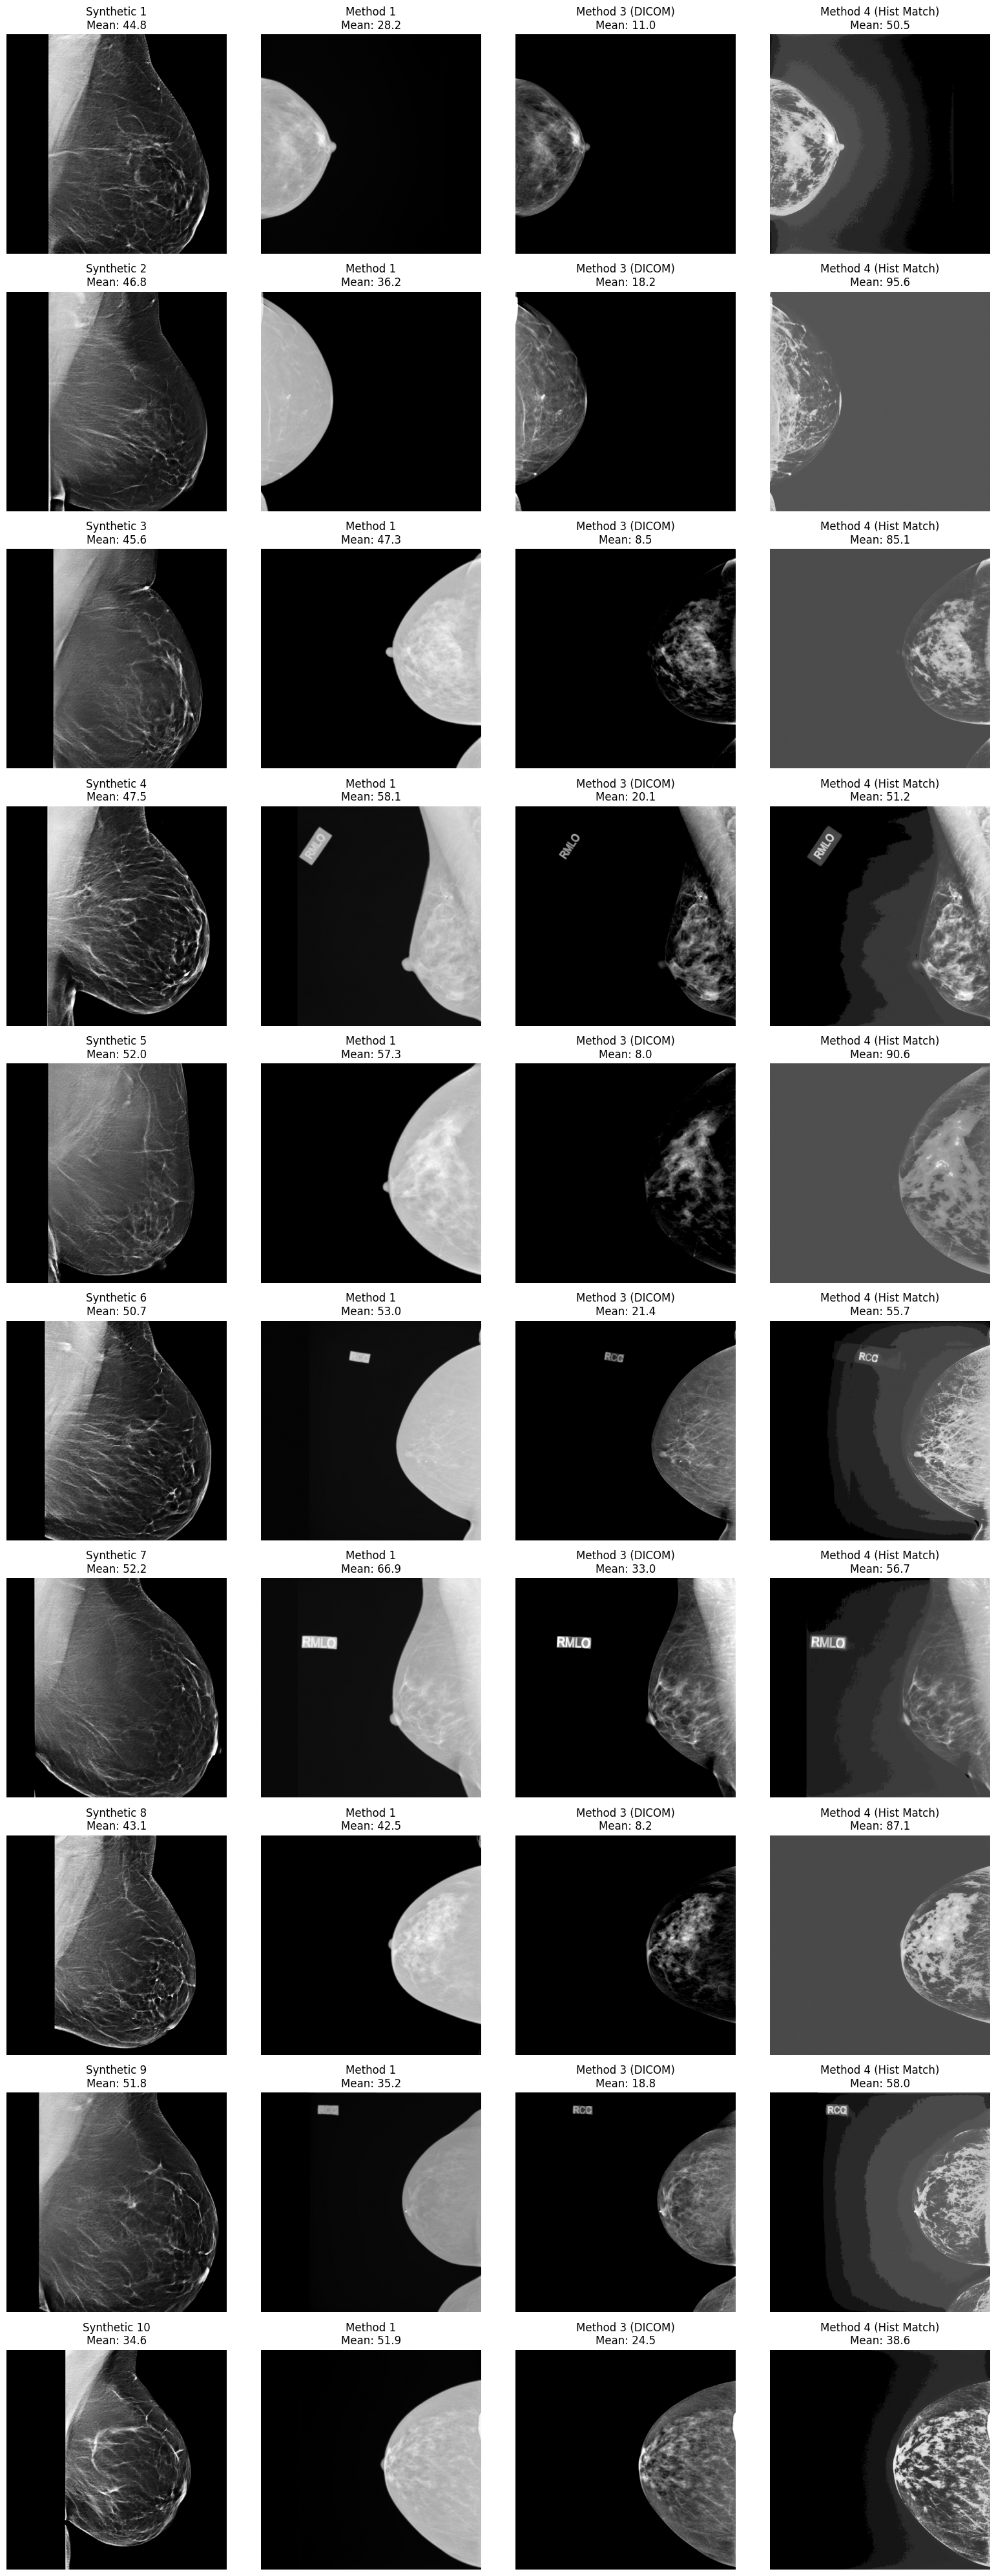


📊 Compare all 10 samples and tell me which method (1, 3, or 4) matches the synthetics best!


In [8]:
from skimage.exposure import match_histograms

# Process 10 samples
num_samples = min(10, len(selected_npz), len(syn_output_files))

fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

print("Processing 10 samples for comparison...\n")

for i in tqdm(range(num_samples), desc="Processing samples"):
    # Load synthetic
    syn_img = cv2.imread(syn_output_files[i], cv2.IMREAD_GRAYSCALE)
    
    # Load and process original NPZ
    npz_file = selected_npz[i]
    npz_data = np.load(npz_file)
    key = npz_data.files[0]
    raw_pixels = npz_data[key]
    
    # Load metadata
    image_id = os.path.splitext(os.path.basename(npz_file))[0]
    json_file = os.path.join(METADATA_PATH, f"{image_id}.json")
    with open(json_file, 'r') as f:
        metadata = json.load(f)
    
    # Method 1: Min-Max
    orig_method1 = ((raw_pixels - raw_pixels.min()) / (raw_pixels.max() - raw_pixels.min()) * 255).astype(np.uint8)
    
    # Method 3: DICOM Windowing
    wc = extract_value(metadata.get('WindowCenter'), 2048.0)
    ww = extract_value(metadata.get('WindowWidth'), 4096.0)
    orig_method3 = apply_dicom_windowing(raw_pixels, wc, ww, 0, 1)
    
    # Method 4: Histogram Matching
    orig_method4 = match_histograms(orig_method1, syn_img).astype(np.uint8)
    
    # Display
    axes[i, 0].imshow(syn_img, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title(f'Synthetic {i+1}\nMean: {syn_img.mean():.1f}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(orig_method1, cmap='gray', vmin=0, vmax=255)
    axes[i, 1].set_title(f'Method 1\nMean: {orig_method1.mean():.1f}')
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(orig_method3, cmap='gray', vmin=0, vmax=255)
    axes[i, 2].set_title(f'Method 3 (DICOM)\nMean: {orig_method3.mean():.1f}')
    axes[i, 2].axis('off')
    
    axes[i, 3].imshow(orig_method4, cmap='gray', vmin=0, vmax=255)
    axes[i, 3].set_title(f'Method 4 (Hist Match)\nMean: {orig_method4.mean():.1f}')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Compare all 10 samples and tell me which method (1, 3, or 4) matches the synthetics best!")


## 🆕 Method 5: Method 3 + Brightness Adjustment

Let's try making Method 3 (clean) match the synthetic brightness!


Processing 10 samples with Method 5 (Method 3 + Brightness Adjustment)...



Processing Method 5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 128.58it/s]
/tmp/ipykernel_3057341/80245003.py:51: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


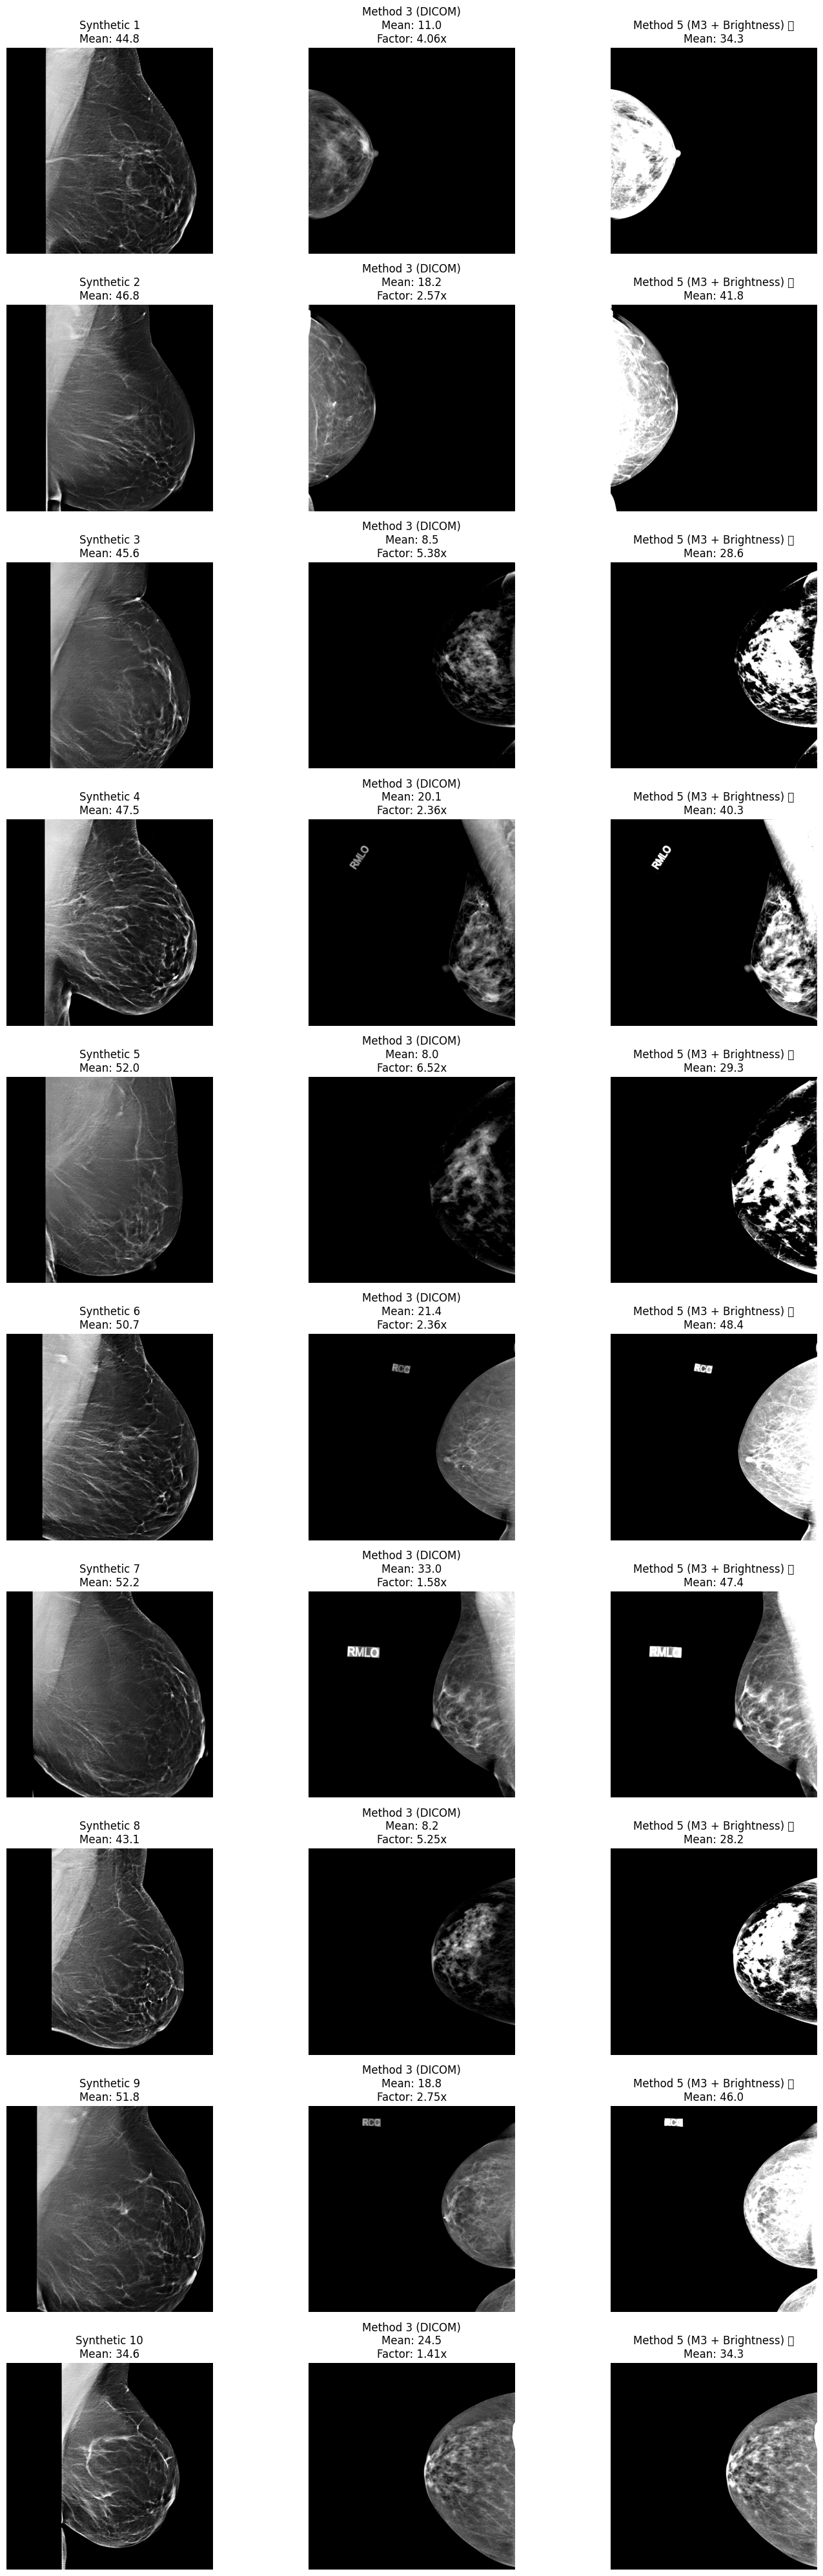


COMPARISON:
Method 3: Clean but dark (uses DICOM windowing)
Method 5: Clean AND matches synthetic brightness!

✨ Method 5 should look almost identical to synthetic!


In [9]:
# Process 10 samples with Method 5
num_samples = min(10, len(selected_npz), len(syn_output_files))

fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4*num_samples))

print("Processing 10 samples with Method 5 (Method 3 + Brightness Adjustment)...\n")

for i in tqdm(range(num_samples), desc="Processing Method 5"):
    # Load synthetic
    syn_img = cv2.imread(syn_output_files[i], cv2.IMREAD_GRAYSCALE)
    
    # Load and process original NPZ
    npz_file = selected_npz[i]
    npz_data = np.load(npz_file)
    key = npz_data.files[0]
    raw_pixels = npz_data[key]
    
    # Load metadata
    image_id = os.path.splitext(os.path.basename(npz_file))[0]
    json_file = os.path.join(METADATA_PATH, f"{image_id}.json")
    with open(json_file, 'r') as f:
        metadata = json.load(f)
    
    # Method 3: DICOM Windowing (clean but dark)
    wc = extract_value(metadata.get('WindowCenter'), 2048.0)
    ww = extract_value(metadata.get('WindowWidth'), 4096.0)
    orig_method3 = apply_dicom_windowing(raw_pixels, wc, ww, 0, 1)
    
    # Method 5: Method 3 + Brightness Adjustment
    synthetic_mean = syn_img.mean()
    original_mean = orig_method3.mean()
    brightness_factor = synthetic_mean / original_mean if original_mean > 0 else 1.0
    
    # Apply brightness adjustment
    orig_method5 = orig_method3.astype(np.float32) * brightness_factor
    orig_method5 = np.clip(orig_method5, 0, 255).astype(np.uint8)
    
    # Display
    axes[i, 0].imshow(syn_img, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title(f'Synthetic {i+1}\nMean: {syn_img.mean():.1f}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(orig_method3, cmap='gray', vmin=0, vmax=255)
    axes[i, 1].set_title(f'Method 3 (DICOM)\nMean: {orig_method3.mean():.1f}\nFactor: {brightness_factor:.2f}x')
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(orig_method5, cmap='gray', vmin=0, vmax=255)
    axes[i, 2].set_title(f'Method 5 (M3 + Brightness) ⭐\nMean: {orig_method5.mean():.1f}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print("Method 3: Clean but dark (uses DICOM windowing)")
print("Method 5: Clean AND matches synthetic brightness!")
print("\n✨ Method 5 should look almost identical to synthetic!")
print("="*70)


In [10]:
print("Processing original NPZ images...\n")

processed_count = 0
errors = []

def extract_value(param, default):
    """Extract numeric value from parameter that might be a list or single value"""
    if isinstance(param, list):
        return float(param[0]) if len(param) > 0 else default
    return float(param) if param is not None else default

for npz_file in tqdm(selected_npz, desc="Processing NPZ files"):
    try:
        # Get image ID (filename without extension)
        image_id = os.path.splitext(os.path.basename(npz_file))[0]
        
        # Load NPZ file
        npz_data = np.load(npz_file)
        
        # Get the array - use first available key
        key = npz_data.files[0]
        raw_pixels = npz_data[key]
        
        # Load corresponding metadata JSON
        json_file = os.path.join(METADATA_PATH, f"{image_id}.json")
        with open(json_file, 'r') as f:
            metadata = json.load(f)
        
        # Extract windowing parameters (handle lists!)
        window_center = extract_value(metadata.get('WindowCenter'), 2048.0)
        window_width = extract_value(metadata.get('WindowWidth'), 4096.0)
        rescale_intercept = extract_value(metadata.get('RescaleIntercept'), 0)
        rescale_slope = extract_value(metadata.get('RescaleSlope'), 1)
        
        # Apply windowing
        windowed_img = apply_dicom_windowing(
            raw_pixels, 
            window_center, 
            window_width,
            rescale_intercept,
            rescale_slope
        )
        
        # Save as PNG
        output_path = os.path.join(ORIGINAL_OUTPUT, f"{image_id}.png")
        cv2.imwrite(output_path, windowed_img)
        
        processed_count += 1
        
    except Exception as e:
        errors.append((image_id, str(e)))

print(f"\n✓ Successfully processed {processed_count}/{len(selected_npz)} images")
print(f"✓ Saved to: {ORIGINAL_OUTPUT}")

if errors:
    print(f"\n⚠ {len(errors)} errors occurred:")
    for img_id, error in errors:
        print(f"  {img_id}: {error}")


Processing original NPZ images...



Processing NPZ files: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 180.14it/s]


✓ Successfully processed 10/10 images
✓ Saved to: /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/test_original_matched


## Step 5: Verify Output and Compare


In [11]:
# Load processed images
synthetic_test = sorted(glob.glob(os.path.join(SYNTHETIC_OUTPUT, '*.png')))
original_test = sorted(glob.glob(os.path.join(ORIGINAL_OUTPUT, '*.png')))

print("="*70)
print("DIMENSION CHECK")
print("="*70)

# Check dimensions
syn_dims = []
for f in synthetic_test:
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    syn_dims.append(img.shape)

orig_dims = []
for f in original_test:
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    orig_dims.append(img.shape)

print(f"\nSynthetic dimensions: {set(syn_dims)}")
print(f"Original dimensions: {set(orig_dims)}")

if set(syn_dims) == set(orig_dims) and set(syn_dims) == {(512, 512)}:
    print("\n✅ SUCCESS: All images are 512x512!")
else:
    print("\n❌ MISMATCH: Dimensions don't match!")


DIMENSION CHECK

Synthetic dimensions: {(512, 512)}
Original dimensions: {(512, 512)}

✅ SUCCESS: All images are 512x512!


In [12]:
# Analyze pixel statistics
print("\n" + "="*70)
print("PIXEL STATISTICS COMPARISON")
print("="*70)

syn_stats = {'min': [], 'max': [], 'mean': [], 'std': []}
orig_stats = {'min': [], 'max': [], 'mean': [], 'std': []}

for f in synthetic_test:
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    syn_stats['min'].append(img.min())
    syn_stats['max'].append(img.max())
    syn_stats['mean'].append(img.mean())
    syn_stats['std'].append(img.std())

for f in original_test:
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    orig_stats['min'].append(img.min())
    orig_stats['max'].append(img.max())
    orig_stats['mean'].append(img.mean())
    orig_stats['std'].append(img.std())

print("\n📊 Synthetic images (resized):")
print(f"  Min: {np.mean(syn_stats['min']):.1f} ± {np.std(syn_stats['min']):.1f}")
print(f"  Max: {np.mean(syn_stats['max']):.1f} ± {np.std(syn_stats['max']):.1f}")
print(f"  Mean: {np.mean(syn_stats['mean']):.1f} ± {np.std(syn_stats['mean']):.1f}")
print(f"  Std: {np.mean(syn_stats['std']):.1f} ± {np.std(syn_stats['std']):.1f}")

print("\n📊 Original images (windowed):")
print(f"  Min: {np.mean(orig_stats['min']):.1f} ± {np.std(orig_stats['min']):.1f}")
print(f"  Max: {np.mean(orig_stats['max']):.1f} ± {np.std(orig_stats['max']):.1f}")
print(f"  Mean: {np.mean(orig_stats['mean']):.1f} ± {np.std(orig_stats['mean']):.1f}")
print(f"  Std: {np.mean(orig_stats['std']):.1f} ± {np.std(orig_stats['std']):.1f}")

mean_diff = abs(np.mean(syn_stats['mean']) - np.mean(orig_stats['mean']))
print(f"\n📈 Mean pixel value difference: {mean_diff:.1f}")

if mean_diff < 10:
    print("✅ Pixel ranges are SIMILAR!")
elif mean_diff < 30:
    print("⚠️ Moderate difference - may need adjustment")
else:
    print("❌ Significant difference - windowing mismatch")



PIXEL STATISTICS COMPARISON

📊 Synthetic images (resized):
  Min: 0.0 ± 0.0
  Max: 254.4 ± 1.8
  Mean: 46.9 ± 5.1
  Std: 54.5 ± 3.6

📊 Original images (windowed):
  Min: 0.0 ± 0.0
  Max: 251.1 ± 10.7
  Mean: 17.2 ± 7.8
  Std: 37.2 ± 10.6

📈 Mean pixel value difference: 29.7
⚠️ Moderate difference - may need adjustment


## Step 6: Side-by-Side Visual Comparison


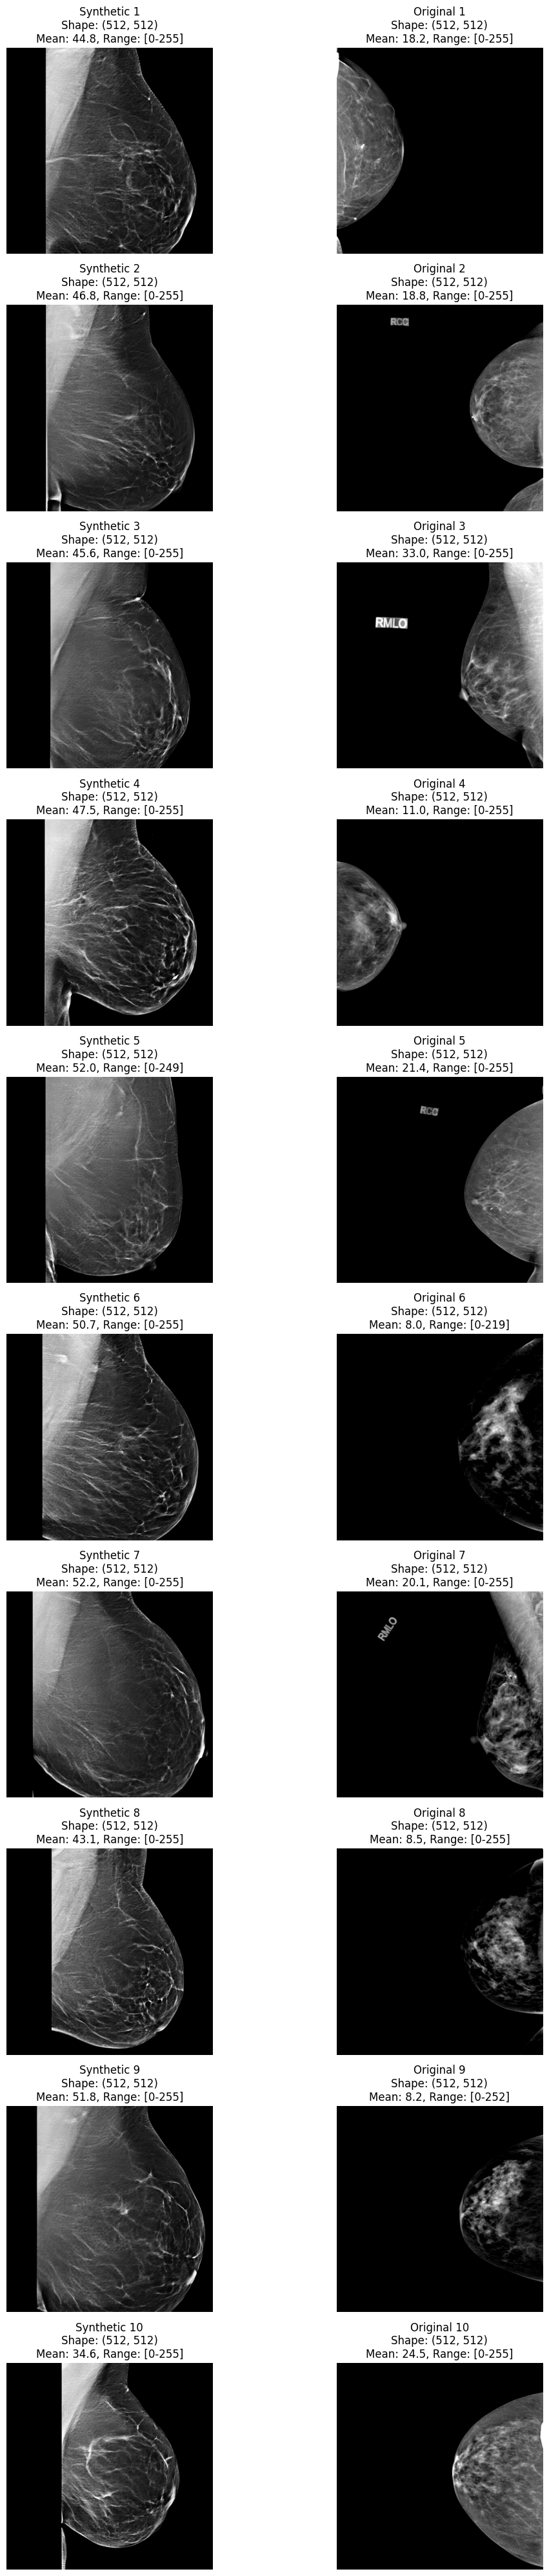


📸 Visual comparison complete - check images above


In [13]:
# Display all 10 pairs side-by-side
num_display = min(10, len(synthetic_test), len(original_test))

fig, axes = plt.subplots(num_display, 2, figsize=(12, 4*num_display))

if num_display == 1:
    axes = axes.reshape(1, -1)

for i in range(num_display):
    # Load images
    syn_img = cv2.imread(synthetic_test[i], cv2.IMREAD_GRAYSCALE)
    orig_img = cv2.imread(original_test[i], cv2.IMREAD_GRAYSCALE)
    
    # Synthetic
    axes[i, 0].imshow(syn_img, cmap='gray')
    axes[i, 0].set_title(f'Synthetic {i+1}\nShape: {syn_img.shape}\nMean: {syn_img.mean():.1f}, Range: [{syn_img.min()}-{syn_img.max()}]')
    axes[i, 0].axis('off')
    
    # Original
    axes[i, 1].imshow(orig_img, cmap='gray')
    axes[i, 1].set_title(f'Original {i+1}\nShape: {orig_img.shape}\nMean: {orig_img.mean():.1f}, Range: [{orig_img.min()}-{orig_img.max()}]')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n📸 Visual comparison complete - check images above")


## Step 7: Histogram Comparison


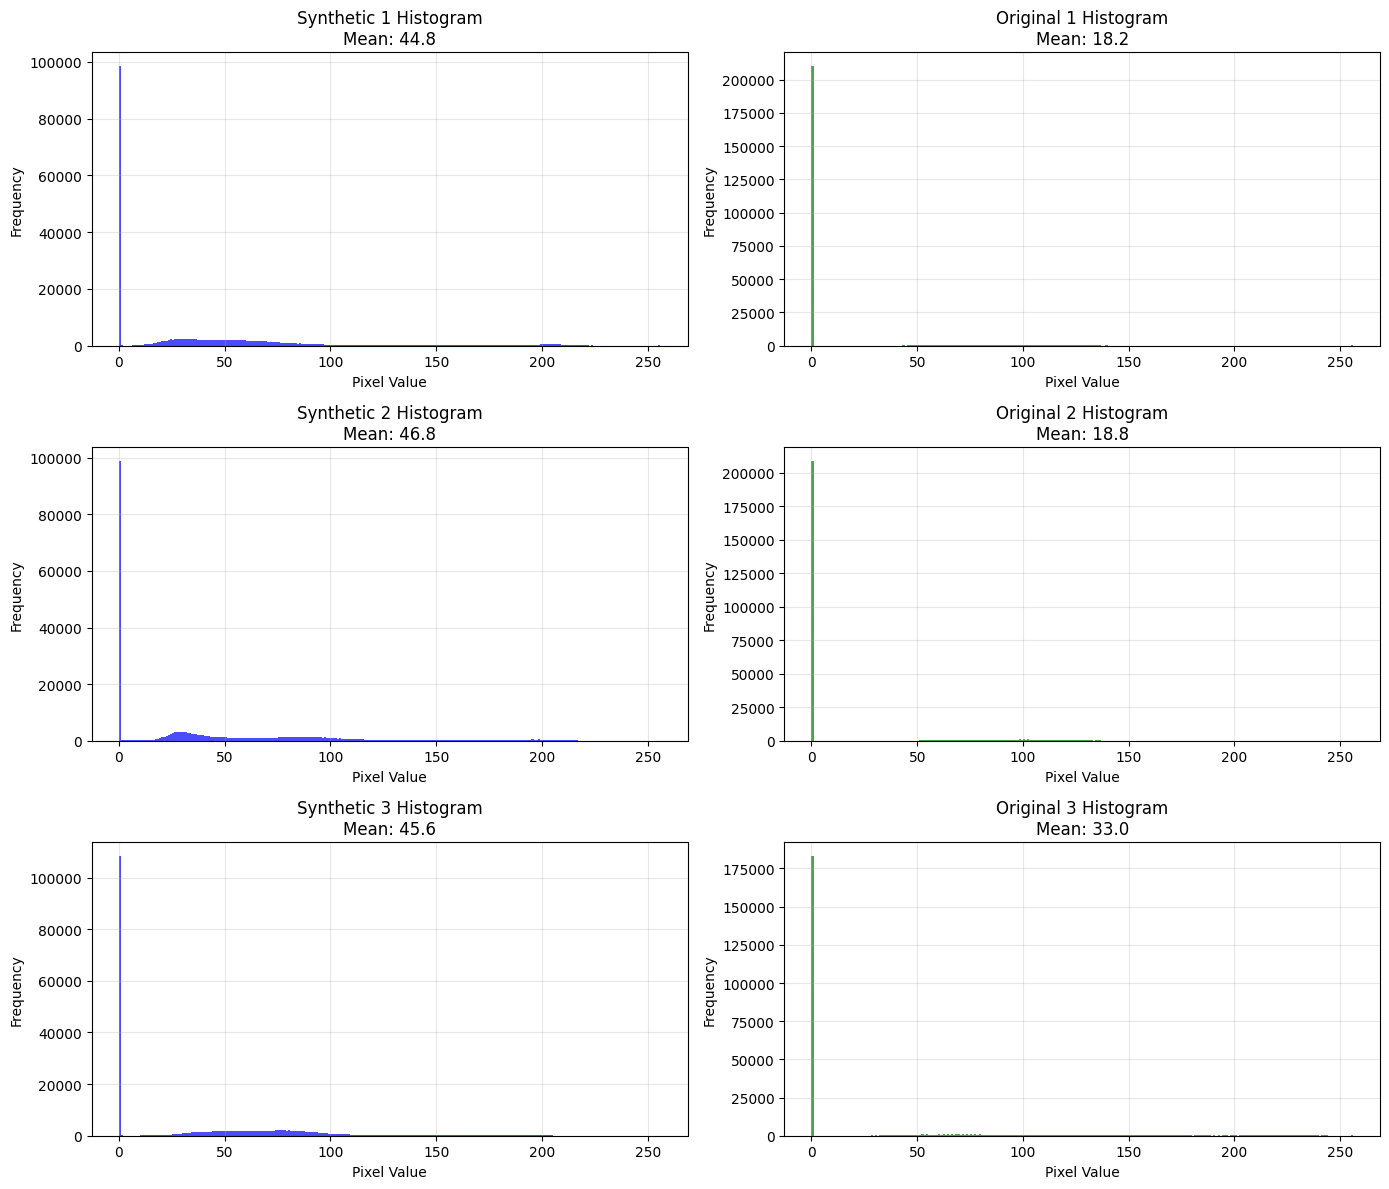


📊 Histogram comparison complete


In [14]:
# Compare histograms of first 3 images from each
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i in range(min(3, len(synthetic_test), len(original_test))):
    syn_img = cv2.imread(synthetic_test[i], cv2.IMREAD_GRAYSCALE)
    orig_img = cv2.imread(original_test[i], cv2.IMREAD_GRAYSCALE)
    
    # Synthetic histogram
    axes[i, 0].hist(syn_img.flatten(), bins=256, range=[0, 256], color='blue', alpha=0.7)
    axes[i, 0].set_title(f'Synthetic {i+1} Histogram\nMean: {syn_img.mean():.1f}')
    axes[i, 0].set_xlabel('Pixel Value')
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Original histogram
    axes[i, 1].hist(orig_img.flatten(), bins=256, range=[0, 256], color='green', alpha=0.7)
    axes[i, 1].set_title(f'Original {i+1} Histogram\nMean: {orig_img.mean():.1f}')
    axes[i, 1].set_xlabel('Pixel Value')
    axes[i, 1].set_ylabel('Frequency')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Histogram comparison complete")


## Final Summary and Next Steps


In [15]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)

print("\n✅ Created 10 test images from each dataset:")
print(f"   Synthetic (resized): {SYNTHETIC_OUTPUT}")
print(f"   Original (windowed): {ORIGINAL_OUTPUT}")

print("\n📏 Dimensions:")
print(f"   Synthetic: {set(syn_dims)}")
print(f"   Original: {set(orig_dims)}")
print(f"   Match: {'✅ YES' if set(syn_dims) == set(orig_dims) else '❌ NO'}")

print("\n📊 Pixel Statistics:")
print(f"   Synthetic mean: {np.mean(syn_stats['mean']):.1f}")
print(f"   Original mean: {np.mean(orig_stats['mean']):.1f}")
print(f"   Difference: {mean_diff:.1f}")

print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("\n👀 Please review the visual comparison and histograms above.")
print("\nIf the images look similar in appearance:")
print("  ✅ We can proceed to process the full dataset")
print("  ✅ Create Notebook 11 to scale this to all images")
print("\nIf they still look very different:")
print("  ⚠️ We may need to adjust the windowing approach")
print("  ⚠️ Consider histogram matching as an additional step")

print("\n" + "="*70)


FINAL SUMMARY

✅ Created 10 test images from each dataset:
   Synthetic (resized): /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/test_synthetic_resized
   Original (windowed): /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/test_original_matched

📏 Dimensions:
   Synthetic: {(512, 512)}
   Original: {(512, 512)}
   Match: ✅ YES

📊 Pixel Statistics:
   Synthetic mean: 46.9
   Original mean: 17.2
   Difference: 29.7

NEXT STEPS:

👀 Please review the visual comparison and histograms above.

If the images look similar in appearance:
  ✅ We can proceed to process the full dataset
  ✅ Create Notebook 11 to scale this to all images

If they still look very different:
  ⚠️ We may need to adjust the windowing approach
  ⚠️ Consider histogram matching as an additional step

